In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Imbalance
from imblearn.over_sampling import SMOTE

# XGBoost
from xgboost import XGBClassifier

import joblib

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("Churn_Modelling.csv")

df.head()

Saving Churn_Modelling.csv to Churn_Modelling.csv


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nInfo:")
df.info()

print("\nMissing Values:\n", df.isnull().sum())

Shape: (10000, 14)

Columns:
 Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-

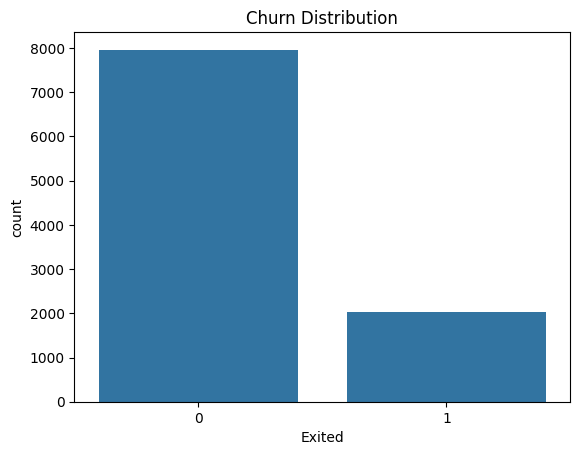

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


In [ ]:
sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution")
plt.show()

print(df['Exited'].value_counts(normalize=True))

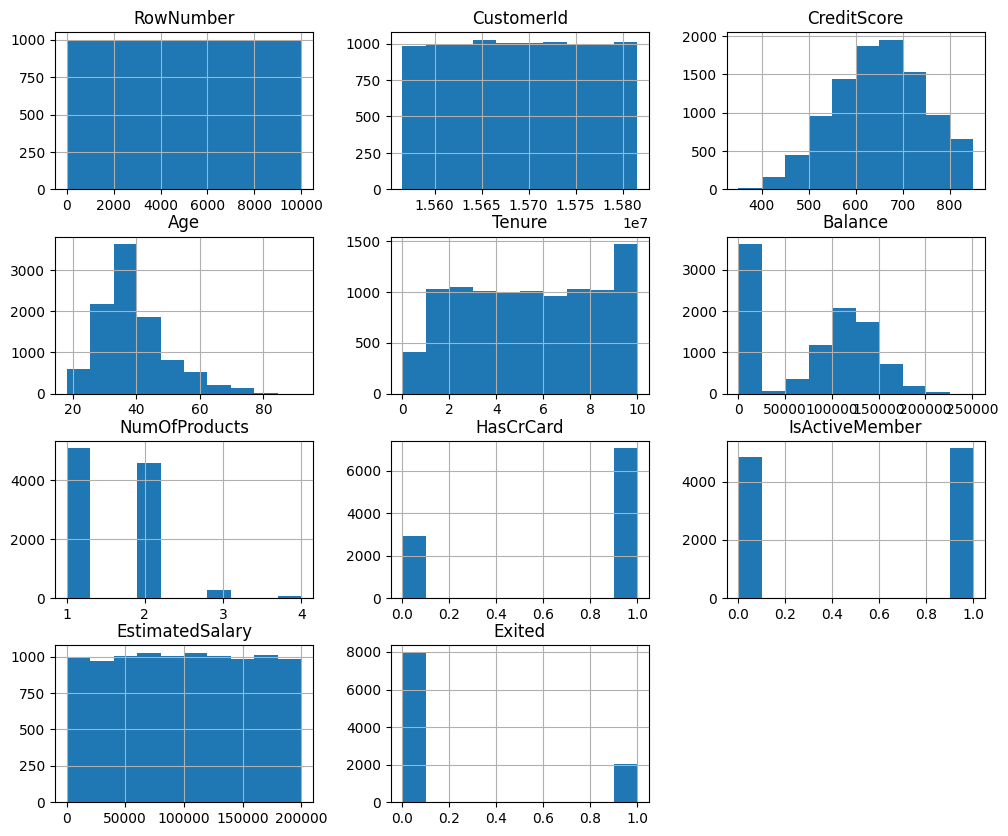

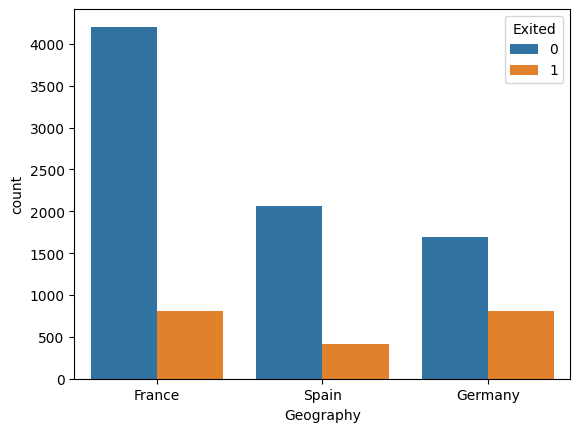

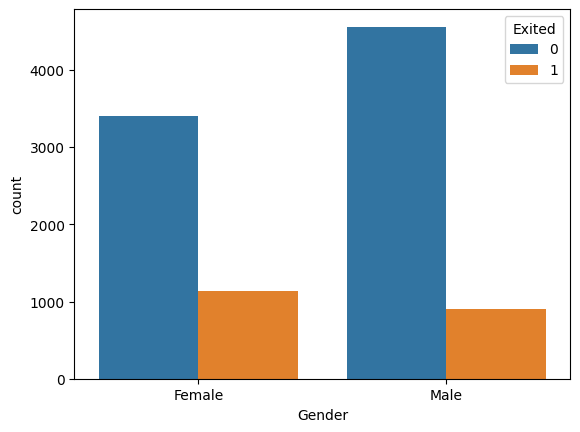

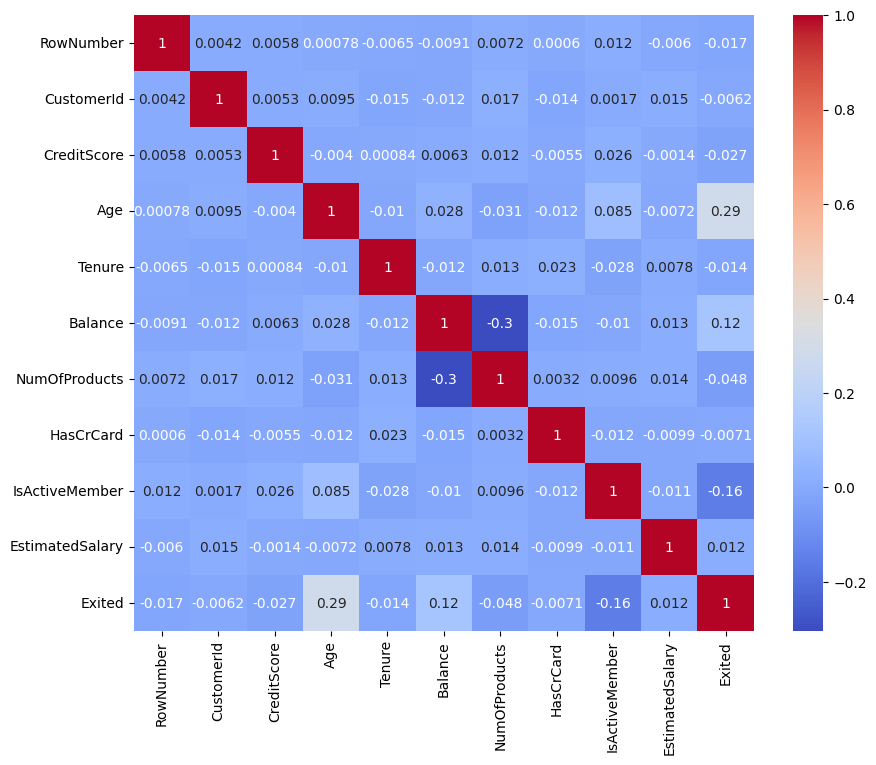

In [ ]:
df.hist(figsize=(12,10))
plt.show()

sns.countplot(x='Geography', hue='Exited', data=df)
plt.show()

sns.countplot(x='Gender', hue='Exited', data=df)
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before:", y_train.value_counts())
print("After:", pd.Series(y_train_smote).value_counts())

Before: Exited
0    6370
1    1630
Name: count, dtype: int64
After: Exited
1    6370
0    6370
Name: count, dtype: int64


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    trained_models[name] = model

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_smote, y_train_smote)

evaluate_model(xgb_model, X_test, y_test)

{'Accuracy': 0.8525,
 'Precision': 0.6352657004830918,
 'Recall': 0.6461916461916462,
 'F1': 0.6406820950060901,
 'ROC-AUC': np.float64(0.8699346495956665)}

In [ ]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [ ]:
results = {}

for name, model in trained_models.items():
    results[name] = evaluate_model(model, X_test, y_test)

results["XGBoost"] = evaluate_model(xgb_model, X_test, y_test)

results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.7155,0.389041,0.697789,0.499560,0.776875
Random Forest,0.8390,0.607595,0.589681,0.598504,0.847716
Gradient Boosting,0.8470,0.615034,0.663391,0.638298,0.866868
XGBoost,0.8525,0.635266,0.646192,0.640682,0.869935


In [ ]:
results_df.sort_values(by="ROC-AUC", ascending=False)

,Accuracy,Precision,Recall,F1,ROC-AUC
XGBoost,0.8525,0.635266,0.646192,0.640682,0.869935
Gradient Boosting,0.8470,0.615034,0.663391,0.638298,0.866868
Random Forest,0.8390,0.607595,0.589681,0.598504,0.847716
Logistic Regression,0.7155,0.389041,0.697789,0.499560,0.776875


In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

search = RandomizedSearchCV(
    XGBClassifier(),
    param_grid,
    n_iter=5,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1
)

search.fit(X_train_smote, y_train_smote)

best_model = search.best_estimator_

print("Best Params:", search.best_params_)

Best Params: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}


In [ ]:
final_results = evaluate_model(xgb_model, X_test, y_test)
final_results

{'Accuracy': 0.8525,
 'Precision': 0.6352657004830918,
 'Recall': 0.6461916461916462,
 'F1': 0.6406820950060901,
 'ROC-AUC': np.float64(0.8699346495956665)}

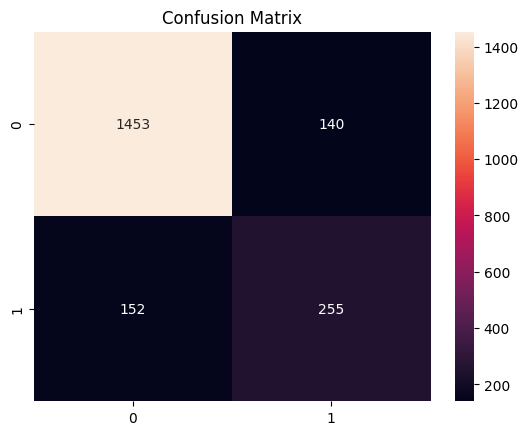

In [ ]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

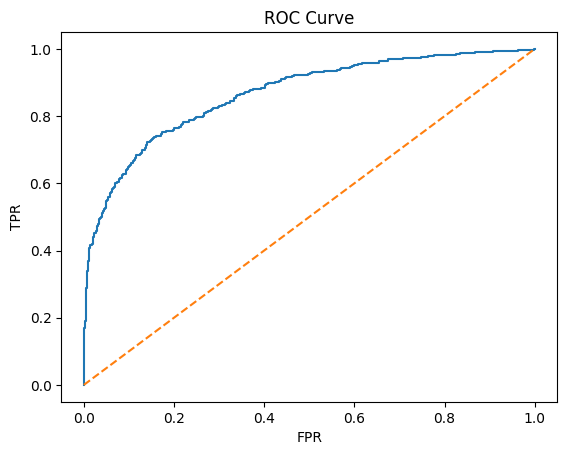

In [ ]:
y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

In [ ]:
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
from google.colab import files

files.download("best_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
sample = X_test[0].reshape(1, -1)

pred = best_model.predict(sample)
prob = best_model.predict_proba(sample)

print("Prediction:", pred)
print("Probability:", prob)

Prediction: [0]
Probability: [[0.9766459  0.02335409]]


In [ ]:
!pip install shap

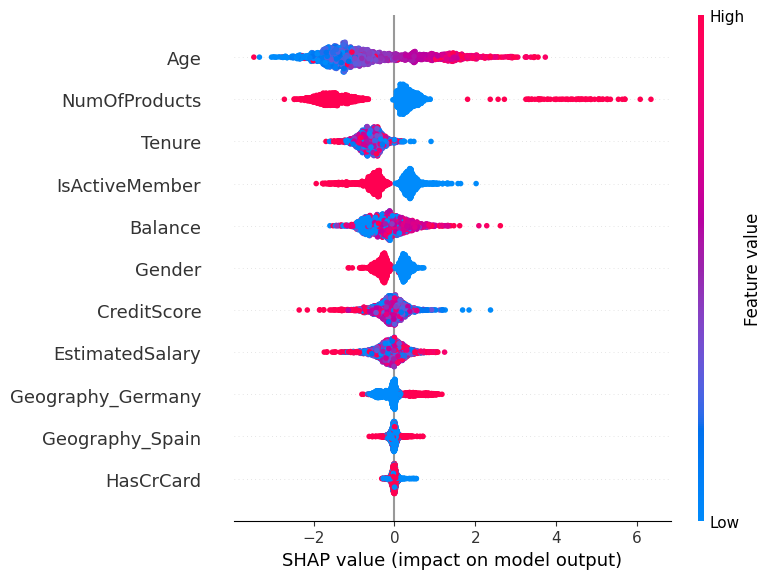

In [ ]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=X.columns)